In [79]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models

from PIL import Image
from torchvision import transforms

In [80]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

In [81]:
model = models.resnet50(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    3
)

In [82]:
checkpoint_path = "best_resnet50.pth"

model.load_state_dict(

    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("ResNet50 model loaded successfully.")

ResNet50 model loaded successfully.


In [83]:
GRADCAM_MASK_DIR = \
    "../outputs/gradcam/masks"

VIT_MASK_DIR = \
    "../outputs/vit/attention_rollout/masks"

TEST_DIR = \
    "../data/COVID_19_dataset/test"

In [84]:
class_to_idx = {

    "COVID": 0,

    "Normal": 1,

    "Viral Pneumonia": 2
}

In [85]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.5159]*3,
        std=[0.2280]*3
    )
])

In [86]:
def load_image(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    tensor = transform(
        image
    )

    return tensor

In [87]:
def compute_entropy(mask):

    mask = mask.flatten()

    mask = mask / (
        mask.sum() + 1e-8
    )

    entropy = -np.sum(

        mask * np.log(
            mask + 1e-8
        )
    )

    return entropy

In [88]:
def evaluate_entropy(mask_dir):

    correct_entropy = []
    wrong_entropy = []

    for file in os.listdir(mask_dir):

        if not file.endswith(".npy"):
            continue

        if (
            "true_" not in file or
            "_pred_" not in file
        ):
            continue

        mask = np.load(
            os.path.join(
                mask_dir,
                file
            )
        )

        entropy = compute_entropy(mask)

        parts = file.replace(
            ".npy",
            ""
        ).split("_")

        try:

            true_class = parts[2]

            pred_class = parts[4]

        except IndexError:

            continue

        if true_class == pred_class:

            correct_entropy.append(
                entropy
            )

        else:

            wrong_entropy.append(
                entropy
            )

    return (
        correct_entropy,
        wrong_entropy
    )

In [89]:
grad_correct, grad_wrong = \
    evaluate_entropy(
        GRADCAM_MASK_DIR
)

vit_correct, vit_wrong = \
    evaluate_entropy(
        VIT_MASK_DIR
)

In [90]:
print(
    "GradCAM Correct Mean:",
    np.mean(grad_correct)
)

print(
    "GradCAM Wrong Mean:",
    np.mean(grad_wrong)
)

print(
    "ViT Correct Mean:",
    np.mean(vit_correct)
)

print(
    "ViT Wrong Mean:",
    np.mean(vit_wrong)
)

GradCAM Correct Mean: 10.360057
GradCAM Wrong Mean: 10.144278
ViT Correct Mean: 10.428987
ViT Wrong Mean: 10.428659


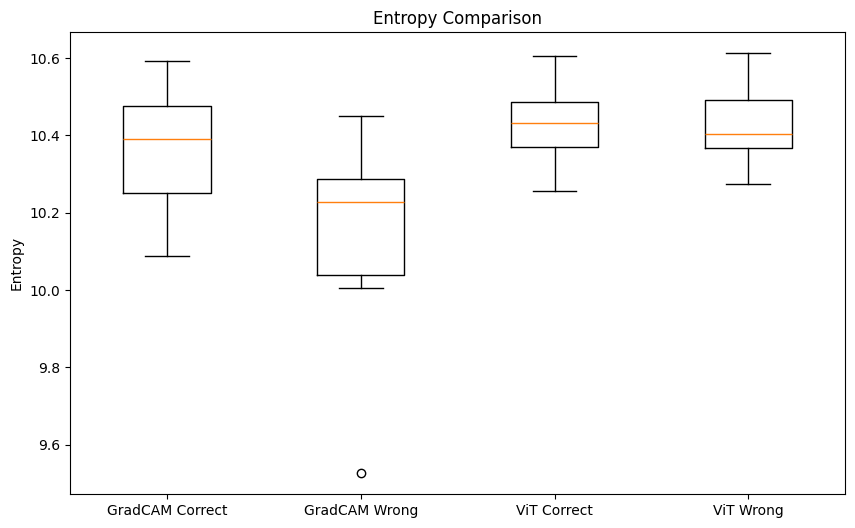

In [91]:
plt.figure(figsize=(10,6))

plt.boxplot([

    grad_correct,
    grad_wrong,

    vit_correct,
    vit_wrong

])

plt.xticks(

    [1,2,3,4],

    [
        "GradCAM Correct",
        "GradCAM Wrong",

        "ViT Correct",
        "ViT Wrong"
    ]
)

plt.ylabel("Entropy")

plt.title(
    "Entropy Comparison"
)

plt.show()

In [92]:
def perturb_image(

    img,
    mask,

    mode='deletion',

    step=0.1
):

    img = img.clone()

    c, h, w = img.shape

    flat_mask = mask.flatten()

    indices = np.argsort(
        flat_mask
    )[::-1].copy()

    num_pixels = int(
        step * len(indices)
    )

    selected = indices[:num_pixels]

    perturbed = img.view(c, -1)

    if mode == 'deletion':

        perturbed[:, selected] = 0

    elif mode == 'insertion':

        original = img.view(c,-1).clone()

        perturbed[:] = 0

        perturbed[:, selected] = \
            original[:, selected]

    return perturbed.view(c,h,w)

In [93]:
def insertion_deletion_curve(

    model,
    image,
    mask,

    target_class
):

    deletion_scores = []
    insertion_scores = []

    steps = np.linspace(
        0.1,
        1.0,
        10
    )

    for step in steps:

        deleted = perturb_image(
            image,
            mask,
            mode='deletion',
            step=step
        )

        inserted = perturb_image(
            image,
            mask,
            mode='insertion',
            step=step
        )

        with torch.no_grad():

            del_out = model(
                deleted.unsqueeze(0).to(device)
            )

            ins_out = model(
                inserted.unsqueeze(0).to(device)
            )

            del_prob = torch.softmax(
                del_out,
                dim=1
            )[0, target_class].item()

            ins_prob = torch.softmax(
                ins_out,
                dim=1
            )[0, target_class].item()

        deletion_scores.append(
            del_prob
        )

        insertion_scores.append(
            ins_prob
        )

    return (
        deletion_scores,
        insertion_scores
    )

In [94]:
sample_mask_file = os.listdir(
    GRADCAM_MASK_DIR
)[0]

print(sample_mask_file)

mask_true_COVID_pred_COVID_0.npy


In [95]:
sample_mask = np.load(

    os.path.join(
        GRADCAM_MASK_DIR,
        sample_mask_file
    )
)

In [96]:
parts = sample_mask_file.replace(
    ".npy",
    ""
).split("_")

true_class = parts[2]

target_class = class_to_idx[
    true_class
]

In [97]:
image_candidates = os.listdir(

    os.path.join(
        TEST_DIR,
        true_class
    )
)

image_path = os.path.join(

    TEST_DIR,

    true_class,

    image_candidates[0]
)

print(image_path)

../data/COVID_19_dataset/test\COVID\COVID-1010.png


In [98]:
sample_image = load_image(
    image_path
)

In [99]:
del_scores, ins_scores = \
    insertion_deletion_curve(

        model,

        sample_image,
        sample_mask,

        target_class
)

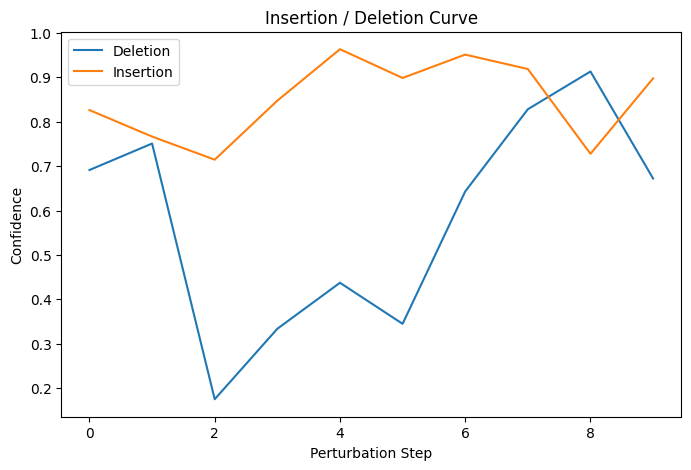

In [100]:
plt.figure(figsize=(8,5))

plt.plot(
    del_scores,
    label='Deletion'
)

plt.plot(
    ins_scores,
    label='Insertion'
)

plt.xlabel(
    "Perturbation Step"
)

plt.ylabel(
    "Confidence"
)

plt.title(
    "Insertion / Deletion Curve"
)

plt.legend()

plt.show()

In [101]:
def compute_aopc(

    model,
    image,
    mask,

    target_class
):

    original_output = model(

        image.unsqueeze(0).to(device)
    )

    original_prob = torch.softmax(

        original_output,
        dim=1

    )[0, target_class].item()

    drops = []

    steps = np.linspace(
        0.1,
        1.0,
        10
    )

    for step in steps:

        deleted = perturb_image(
            image,
            mask,
            mode='deletion',
            step=step
        )

        output = model(
            deleted.unsqueeze(0).to(device)
        )

        prob = torch.softmax(
            output,
            dim=1
        )[0, target_class].item()

        drops.append(
            original_prob - prob
        )

    return np.mean(drops)

In [102]:
gradcam_aopc = compute_aopc(

    model,

    sample_image,
    sample_mask,

    target_class
)

print(
    "GradCAM AOPC:",
    gradcam_aopc
)

GradCAM AOPC: 0.31856527328491213


In [103]:
vit_mask_file = os.listdir(
    VIT_MASK_DIR
)[0]

vit_mask = np.load(

    os.path.join(
        VIT_MASK_DIR,
        vit_mask_file
    )
)

In [104]:
vit_aopc = compute_aopc(

    model,

    sample_image,
    vit_mask,

    target_class
)

print(
    "ViT Rollout AOPC:",
    vit_aopc
)

ViT Rollout AOPC: 0.1361386626958847


In [105]:
results = {

    "Method":[
        "GradCAM",
        "ViT Rollout"
    ],

    "Entropy":[
        np.mean(grad_correct),
        np.mean(vit_correct)
    ],

    "AOPC":[
        gradcam_aopc,
        vit_aopc
    ]
}

df = pd.DataFrame(
    results
)

df

,Method,Entropy,AOPC
0,GradCAM,10.360057,0.318565
1,ViT Rollout,10.428987,0.136139
